In [13]:
%pip install pandas numpy scikit-learn xgboost joblib shap matplotlib

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import joblib
import shap
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


Load Data

In [ ]:
X_train = pd.read_csv("./Data/Dataset/x_train.csv")
X_test  = pd.read_csv("./Data/Dataset/x_test.csv")
y_train = pd.read_csv("./Data/Dataset/y_train.csv").squeeze()  # squeeze to Series
y_test  = pd.read_csv("./Data/Dataset/y_test.csv").squeeze()

Evaluation Helper Function

In [ ]:
# takes any trained model and prints
# all required metrics, then plots the confusion matrix.
def evaluate(name, model, X, y):
    preds = model.predict(X)
    acc  = accuracy_score(y, preds)
    prec = precision_score(y, preds)
    rec  = recall_score(y, preds)
    f1   = f1_score(y, preds)
    cm   = confusion_matrix(y, preds)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}  (of predicted positives, how many were right)")
    print(f"  Recall   : {rec:.4f}  (of actual positives, how many did we catch)")
    print(f"  F1 Score : {f1:.4f}  (harmonic mean of precision & recall)")
    print(f"\n  Confusion Matrix:")
    print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"  FN={cm[1,0]}  TP={cm[1,1]}")
    print(f"\n  Best params: {model.best_params_}")

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
    plt.tight_layout()
    plt.savefig(f"./Data/Summary/ConfusionMatrices/cm_{name.replace(' ', '_')}.png", dpi=150)
    plt.close()

    return {"Model": name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "TN": cm[0,0], "FP": cm[0,1],
            "FN": cm[1,0], "TP": cm[1,1]}

In [16]:
results = []

Logistic Regression

In [17]:
print("Training Logistic Regression...")

lr_params = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    cv=5,           # 5-fold cross-validation
    scoring='accuracy',   # optimise for accuracy
    n_jobs=-1
)
lr.fit(X_train, y_train)
results.append(evaluate("Logistic Regression", lr, X_test, y_test))

Training Logistic Regression...

  Logistic Regression
  Accuracy : 0.8364
  Precision: 0.8261  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8085  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=27  FP=4
  FN=5  TP=19

  Best params: {'C': 0.1, 'solver': 'lbfgs'}


SVM

In [6]:
print("Training SVM...")

svm_params = {
    'C':      [0.1, 1, 10, 100],   # regularisation strength — controls the
                                    # margin width vs. misclassification trade-off
    'kernel': ['linear', 'rbf']     # linear = straight boundary, rbf = curved
                                    # boundary for non-linearly separable data
}

svm = GridSearchCV(
    SVC(probability=True,    # needed so the model can output confidence scores,
                             # not just hard labels — required by some downstream steps
        random_state=42),    # makes results reproducible across runs
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svm.fit(X_train, y_train)
results.append(evaluate("SVM", svm, X_test, y_test))

Training SVM...

  SVM
  Accuracy : 0.8182
  Precision: 0.7917  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.7917  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=26  FP=5
  FN=5  TP=19

  Best params: {'C': 0.1, 'kernel': 'linear'}


Decision Tree

In [7]:
print("Training Decision Tree...")

dt_params = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split':[2, 5, 10, 20]
}

dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
dt.fit(X_train, y_train)
results.append(evaluate("Decision Tree", dt, X_test, y_test))

Training Decision Tree...

  Decision Tree
  Accuracy : 0.8545
  Precision: 0.8636  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8261  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=28  FP=3
  FN=5  TP=19

  Best params: {'max_depth': 3, 'min_samples_split': 2}


Random Forest

In [8]:
print("Training Random Forest...")

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, 10, None]
}

rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", rf, X_test, y_test))

Training Random Forest...

  Random Forest
  Accuracy : 0.8909
  Precision: 0.9500  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8636  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=30  FP=1
  FN=5  TP=19

  Best params: {'max_depth': 3, 'n_estimators': 50}


XGBoost

In [9]:
print("Training XGBoost...")

xgb_params = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth':     [3, 5, 7]
}

xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
xgb.fit(X_train, y_train)
results.append(evaluate("XGBoost", xgb, X_test, y_test))

Training XGBoost...

  XGBoost
  Accuracy : 0.8364
  Precision: 0.8261  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8085  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=27  FP=4
  FN=5  TP=19

  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


K-NN

In [10]:
print("Training KNN...")

knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'metric':      ['euclidean', 'manhattan']
}

knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn.fit(X_train, y_train)
results.append(evaluate("KNN", knn, X_test, y_test))

Training KNN...

  KNN
  Accuracy : 0.8182
  Precision: 0.8182  (of predicted positives, how many were right)
  Recall   : 0.7500  (of actual positives, how many did we catch)
  F1 Score : 0.7826  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=27  FP=4
  FN=6  TP=18

  Best params: {'metric': 'manhattan', 'n_neighbors': 11}


In [19]:
models = {"Logistic Regression": LogisticRegression(), "Support Vector Machine": SVC(), "Decision Tree": DecisionTreeClassifier(), "Random Forest": RandomForestClassifier(), "XGBoost": XGBClassifier(), "KNN": KNeighborsClassifier()}

RFECV

Running combined RFECV + GridSearchCV pipeline...
(This takes longer than a standard GridSearchCV -- that's expected.)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters : {'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Optimal feature count: 20 / 21

Selected features:
  v Age
  v Gender
  v Chest pain type
  v BP
  v Cholesterol
  v FBS over 120
  v EKG results
  v Max HR
  v Exercise angina
  v ST depression
  v Slope of ST
  v Number of vessels fluro
  v Thallium
  v work_type_Govt_job
  v work_type_Private
  v work_type_Self-employed
  v smoking_status_Unknown
  v smoking_status_formerly smoked
  v smoking_status_never smoked
  v smoking_status_smokes

Dropped features:
  x work_type_Unknown


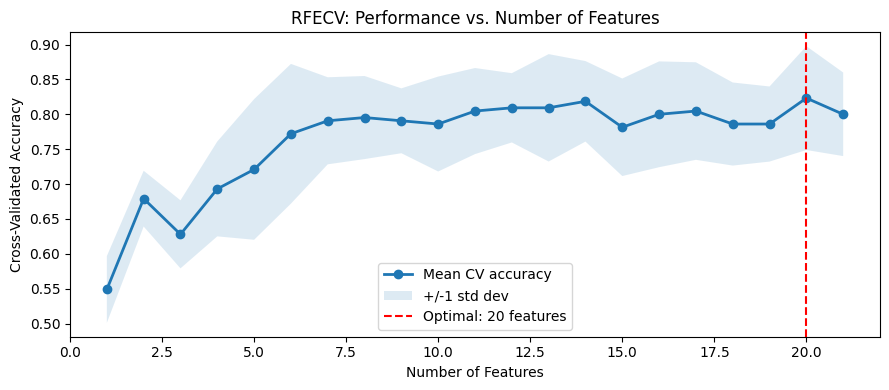


  RF + RFECV Pipeline
  Accuracy : 0.8909
  Precision: 0.9500  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8636  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=30  FP=1
  FN=5  TP=19

  Best params: {'classifier__max_depth': 3, 'classifier__n_estimators': 200}


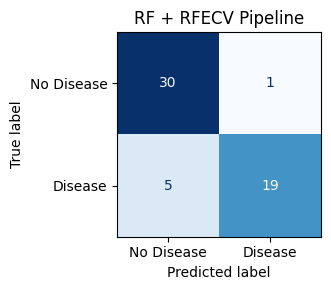

In [ ]:
""" for model in base_models:
    print(f"Running combined RFECV + GridSearchCV pipeline for {model}...")

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Build the Pipeline
    # A Pipeline chains steps so they behave as a single unit. When GridSearchCV
    # creates a fold, it runs the ENTIRE pipeline on that fold -- meaning feature
    # selection happens fresh on each fold's training data and never peeks at the
    # validation data. This is the correctness guarantee that running RFECV and
    # GridSearchCV separately does NOT provide.
    #
    # There are two RF instances here -- this is intentional, not redundant.
    # The one inside RFECV is a 'scout' that ranks and eliminates features.
    # The final 'classifier' step is the model that actually makes predictions.
    pipeline = Pipeline([
        ("feature_selection", RFECV(
            estimator=model(random_state=42),
            step=1,                    # eliminate one feature per round
            cv=cv_strategy,            # RFECV's own inner CV to find optimal count
            scoring='accuracy',
            min_features_to_select=1,
            n_jobs=-1
        )),
        ("classifier", model(random_state=42))
    ])

    # Parameter grid
    # The double-underscore syntax reaches inside the pipeline to tune a specific
    # step. 'classifier__n_estimators' means: the n_estimators parameter of the
    # step named 'classifier'. This is why we named the steps explicitly above.
    param_grid = {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__max_depth":    [3, 5, 10, None]
    }

    # Outer GridSearchCV
    # For every hyperparameter combination, it runs the full pipeline (RFECV +
    # classifier) through cv_strategy folds. Hyperparameters are tuned honestly --
    # they account for the feature selection happening as part of the same process.
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv_strategy,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train) """

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Each entry is: (display name, pipeline, param_grid)
# KNN and SVM (rbf) are excluded — KNN has no feature importances,
# and SVM with rbf kernel has no coef_ either. SVM with a linear
# kernel does expose coef_ and could be included, but it's already
# in your individual models section so there's no need to duplicate it.
pipeline_configs = [
    (
        "LR + RFECV",
        Pipeline([
            ("selector",    RFECV(estimator=LogisticRegression(max_iter=1000, random_state=42),
                                  step=1, cv=cv_strategy, scoring='accuracy',
                                  min_features_to_select=1, n_jobs=-1)),
            ("classifier",  LogisticRegression(max_iter=1000, random_state=42))
        ]),
        {
            "classifier__C":      [0.01, 0.1, 1, 10, 100],
            "classifier__solver": ['lbfgs', 'liblinear']
        }
    ),
    (
        "SVM + RFECV",
        Pipeline([
            ("selector",   RFECV(estimator=SVC(kernel='linear',  # must be linear --
                                            probability=True,  # coef_ only exists
                                            random_state=42),  # for linear kernel
                                step=1, cv=cv_strategy, scoring='accuracy',
                                min_features_to_select=1, n_jobs=-1)),
            ("classifier", SVC(probability=True, random_state=42))
        ]),
        {
            "classifier__C":      [0.1, 1, 10, 100],
            "classifier__kernel": ['linear', 'rbf']
                                # RFECV selected features using a linear SVM,
                                # but the final classifier is free to use rbf
                                # on that reduced feature set -- GridSearchCV
                                # will find whichever kernel performs better
        }
    ),
    (
        "RF + RFECV",
        Pipeline([
            ("selector",    RFECV(estimator=RandomForestClassifier(random_state=42),
                                  step=1, cv=cv_strategy, scoring='accuracy',
                                  min_features_to_select=1, n_jobs=-1)),
            ("classifier",  RandomForestClassifier(random_state=42))
        ]),
        {
            "classifier__n_estimators": [50, 100, 200],
            "classifier__max_depth":    [3, 5, 10, None]
        }
    ),
    (
        "DT + RFECV",
        Pipeline([
            ("selector",    RFECV(estimator=DecisionTreeClassifier(random_state=42),
                                  step=1, cv=cv_strategy, scoring='accuracy',
                                  min_features_to_select=1, n_jobs=-1)),
            ("classifier",  DecisionTreeClassifier(random_state=42))
        ]),
        {
            "classifier__max_depth":         [3, 5, 7, 10, None],
            "classifier__min_samples_split":  [2, 5, 10, 20]
        }
    ),
    (
        "XGB + RFECV",
        Pipeline([
            ("selector",    RFECV(estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
                                  step=1, cv=cv_strategy, scoring='accuracy',
                                  min_features_to_select=1, n_jobs=-1)),
            ("classifier",  XGBClassifier(random_state=42, eval_metric='logloss'))
        ]),
        {
            "classifier__n_estimators":  [50, 100, 200],
            "classifier__learning_rate": [0.01, 0.1, 0.3],
            "classifier__max_depth":     [3, 5, 7]
        }
    ),
]

# Run all pipelines and collect results
for name, pipeline, param_grid in pipeline_configs:
    print(f"\nRunning {name}...")

    gs = GridSearchCV(pipeline, param_grid, cv=cv_strategy,
                      scoring='accuracy', n_jobs=-1, verbose=1)
    gs.fit(X_train, y_train)

    best_pipe  = gs.best_estimator_
    best_sel   = best_pipe.named_steps["selector"]
    selected   = X_train.columns[best_sel.support_].tolist()

    print(f"  Best params   : {gs.best_params_}")
    print(f"  Features kept : {best_sel.n_features_} / {X_train.shape[1]} -> {selected}")

    results.append(evaluate(name, best_pipe, X_test, y_test))
    models[name] = best_pipe

    # Inspect results
    best_pipeline     = gs.best_estimator_
    best_rfecv        = best_pipeline.named_steps["feature_selection"]
    best_rf           = best_pipeline.named_steps["classifier"]
    selected_features = X_train.columns[best_rfecv.support_].tolist()
    dropped_features  = X_train.columns[~best_rfecv.support_].tolist()

    print(f"Best hyperparameters : {gs.best_params_}")
    print(f"Optimal feature count: {best_rfecv.n_features_} / {X_train.shape[1]}")
    print(f"\nSelected features:")
    for f in selected_features:
        print(f"  v {f}")
    print(f"\nDropped features:")
    for f in dropped_features:
        print(f"  x {f}")

    # RFECV performance curve
    # Shows CV accuracy at every feature count evaluated. The shape matters as much
    # as the peak -- a flat plateau means many features are redundant; a sharp drop
    # after the peak means the selected features carry most of the signal.
    mean_scores    = best_rfecv.cv_results_["mean_test_score"]
    std_scores     = best_rfecv.cv_results_["std_test_score"]
    feature_counts = range(1, len(mean_scores) + 1)

    plt.figure(figsize=(9, 4))
    plt.plot(feature_counts, mean_scores, marker='o', linewidth=2, label='Mean CV accuracy')
    plt.fill_between(
        feature_counts,
        mean_scores - std_scores,
        mean_scores + std_scores,
        alpha=0.15, label='+/-1 std dev'
    )
    plt.axvline(
        x=best_rfecv.n_features_,
        color='red', linestyle='--',
        label=f'Optimal: {best_rfecv.n_features_} features'
    )
    plt.xlabel('Number of Features')
    plt.ylabel('Cross-Validated Accuracy')
    plt.title('RFECV: Performance vs. Number of Features')
    plt.legend()
    plt.tight_layout()
    plt.savefig("./Data/Summary/RFECV/rfecv_curve.png", dpi=150)
    plt.show()

# Evaluate on test set
# pipeline.predict(X_test) automatically applies the stored feature mask before
# predicting -- no need to manually filter X_test first.
preds = best_pipeline.predict(X_test)
acc   = accuracy_score(y_test, preds)
prec  = precision_score(y_test, preds)
rec   = recall_score(y_test, preds)
f1    = f1_score(y_test, preds)
cm    = confusion_matrix(y_test, preds)

print(f"\n{'='*45}")
print(f"  RF + RFECV Pipeline")
print(f"{'='*45}")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}  (of predicted positives, how many were right)")
print(f"  Recall   : {rec:.4f}  (of actual positives, how many did we catch)")
print(f"  F1 Score : {f1:.4f}  (harmonic mean of precision & recall)")
print(f"\n  Confusion Matrix:")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")
print(f"\n  Best params: {gs.best_params_}")

fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("RF + RFECV Pipeline")
plt.tight_layout()
plt.savefig("./Data/Summary/ConfusionMatrices/cm_RF_RFECV_Pipeline.png", dpi=150)
plt.show()

results.append({"Model": "RF + RFECV Pipeline", "Accuracy": acc,
                "Precision": prec, "Recall": rec, "F1": f1,
                "TN": cm[0,0], "FP": cm[0,1], "FN": cm[1,0], "TP": cm[1,1]})

# Add to models dict so the Save Model cell can pick it up if it wins
models["RF + RFECV Pipeline"] = best_pipeline


Summary

In [ ]:
print("\n\n" + "="*55)
print("  MODEL COMPARISON SUMMARY")
print("="*55)

summary = pd.DataFrame(results)[["Model", "Accuracy", "Precision", "Recall", "F1"]]
summary = summary.sort_values("F1", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

summary.to_csv("./Data/Summary/model_summary.csv", index=False)
print("\nSummary saved to ./Data/Summary/model_summary.csv")
print("Confusion matrix plots saved to ./Data/Summary/")

Save Model

In [ ]:
max_acc = 0
best_model_name = ""
for name in results:
    if name["Accuracy"] > max_acc:
        max_acc = name["Accuracy"]
        best_model_name = name["Model"]
print(f"\nBest model: {best_model_name} with accuracy: {max_acc:.4f}")
best_model = models[best_model_name]
joblib.dump(best_model, './Models/heart_disease_model.pkl')

Feature Importance

In [ ]:
# If the best model is a Pipeline (e.g. RF + RFECV Pipeline won), we unwrap
# it to get the underlying RF and the reduced feature set. SHAP needs a plain
# model and data with a matching column count -- not a pipeline wrapper.
if hasattr(best_model, 'named_steps'):
    rf_model = best_model.named_steps["classifier"]
    selected = X_train.columns[best_model.named_steps["feature_selection"].support_]
    X_shap   = X_test[selected]
else:
    # Plain model -- use all features as before
    rf_model = best_model
    selected = X_test.columns
    X_shap   = X_test

try:
    explainer   = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_shap)

    # For binary classification, TreeExplainer returns a list: [class_0, class_1]
    # We plot class 1 (Disease = positive class) -- the medically meaningful side
    plot_values = shap_values[1] if isinstance(shap_values, list) else shap_values

except Exception:
    # Fallback for non-tree models
    explainer   = shap.Explainer(rf_model.predict, X_shap)
    shap_values = explainer(X_shap)
    plot_values = shap_values.values

shap.summary_plot(
    plot_values,
    X_shap,
    feature_names=selected.tolist(),
    max_display=10,
    plot_type="dot"
)


In [ ]:
# ─────────────────────────────────────────────
# MODEL 1 — LOGISTIC REGRESSION
#
# How it works: finds a linear boundary in feature
# space that best separates the two classes. The
# output is a probability, which is then thresholded
# at 0.5 to produce a class label.
#
# Hyperparameters we vary:
#
# C — the inverse of regularisation strength.
#   A small C means strong regularisation, which
#   shrinks coefficients toward zero and prevents
#   overfitting. A large C gives the model more
#   freedom to fit the training data.
#
# solver — the optimisation algorithm used to find
#   the best coefficients. 'lbfgs' and 'liblinear'
#   are both good for small datasets like this one.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# MODEL 2 — DECISION TREE
#
# How it works: recursively splits the data on the
# feature/threshold that best separates the classes,
# forming a tree of if/else rules. Very interpretable
# — you can literally follow the path from root to
# leaf to understand any individual prediction.
#
# Hyperparameters we vary:
#
# max_depth — how deep the tree is allowed to grow.
#   A shallow tree underfits (misses patterns); a
#   very deep tree overfits (memorises training data).
#
# min_samples_split — the minimum number of samples
#   a node must have before it can be split further.
#   Higher values make the tree more conservative and
#   less likely to create splits that only explain
#   one or two training examples.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# MODEL 3 — RANDOM FOREST
#
# How it works: builds many decision trees, each
# trained on a random subset of rows (bagging) and
# a random subset of features at each split. The
# final prediction is a majority vote across all
# trees. This reduces the variance that single
# decision trees are prone to.
#
# Hyperparameters we vary:
#
# n_estimators — the number of trees in the forest.
#   More trees generally means better performance up
#   to a point, after which returns diminish. More
#   trees also means longer training time.
#
# max_depth — same concept as in the Decision Tree,
#   but now applied to each individual tree in the
#   forest. Shallower trees mean more bias but less
#   variance — the ensemble compensates for the bias.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# MODEL 4 (BONUS) — XGBOOST
#
# How it works: like Random Forest, XGBoost builds
# many trees — but instead of building them in
# parallel independently, it builds them sequentially.
# Each new tree focuses on correcting the errors the
# previous trees made. This is called gradient
# boosting, and it tends to produce very accurate
# results on structured/tabular data.
#
# Hyperparameters we vary:
#
# n_estimators — number of boosting rounds (trees).
#   Unlike Random Forest, more rounds can lead to
#   overfitting, so this needs to be tuned carefully.
#
# learning_rate — how much each new tree's contribution
#   is scaled down before being added to the ensemble.
#   A lower rate means each tree contributes less,
#   requiring more trees to reach the same performance
#   — but typically generalises better.
#
# max_depth — depth of each individual tree. XGBoost
#   trees are typically kept shallow (3-6) because
#   the boosting process itself adds complexity.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# MODEL 5 (BONUS) — K-NEAREST NEIGHBORS (KNN)
#
# How it works: no training in the traditional sense.
# Instead, when predicting a new patient, KNN finds
# the k most similar patients in the training set
# (using distance in feature space) and takes a
# majority vote of their labels. It's entirely
# instance-based — the "model" is just the training
# data itself.
#
# This is the primary reason StandardScaler was applied
# in preprocessing. Without scaling, Age (range ~50)
# and Cholesterol (range ~200+) would completely
# dominate the distance calculation, drowning out
# binary features like Gender or Exercise Angina.
# Scaling puts all features on equal footing.
#
# Hyperparameters we vary:
#
# n_neighbors (k) — how many neighbours vote on the
#   prediction. Small k = sensitive to noise (overfits);
#   large k = smoother boundary (underfits). Finding
#   the right k is the central tuning challenge in KNN.
#
# metric — the distance function used to measure
#   similarity. 'euclidean' is straight-line distance.
#   'manhattan' sums absolute differences dimension by
#   dimension. On high-dimensional data, manhattan
#   often generalises better than euclidean.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# SUMMARY TABLE
#
# A side-by-side comparison of all models makes it
# easy to identify which performed best and where
# each model's strengths and weaknesses lie.
# ─────────────────────────────────────────────